In [ ]:
#Step 1: Import Required Libraries:

In [6]:
!pip install tensorflow

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
#Step 2: Load Dataset:

In [40]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


In [41]:
#Step 3: Visualize Sample Images:

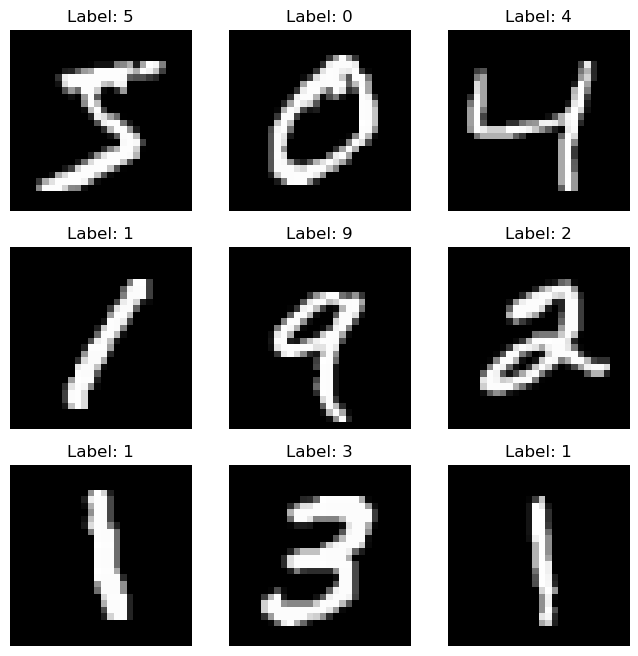

In [42]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

In [43]:
#Step 4: Data Preprocessing:

In [44]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to CNN format
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Convert labels to categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [45]:
#Step 5: Build CNN Model:

In [46]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
#Step 6: Train the Model:

In [48]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.9513 - loss: 0.1585 - val_accuracy: 0.9842 - val_loss: 0.0449
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - accuracy: 0.9827 - loss: 0.0563 - val_accuracy: 0.9872 - val_loss: 0.0389
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9905 - val_loss: 0.0280
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9918 - val_loss: 0.0246
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.9919 - loss: 0.0268 - val_accuracy: 0.9919 - val_loss: 0.0236
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9905 - val_loss: 0.0285
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9939 - loss: 0.0192 - val_accuracy: 0.9910 - val_loss: 0.0285
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9951 -

In [49]:
#Step 7: Evaluate Model:

In [50]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9920 - loss: 0.0319
Test Accuracy: 0.9919999837875366


In [51]:
#Step 8: Plot Training Accuracy and Loss:

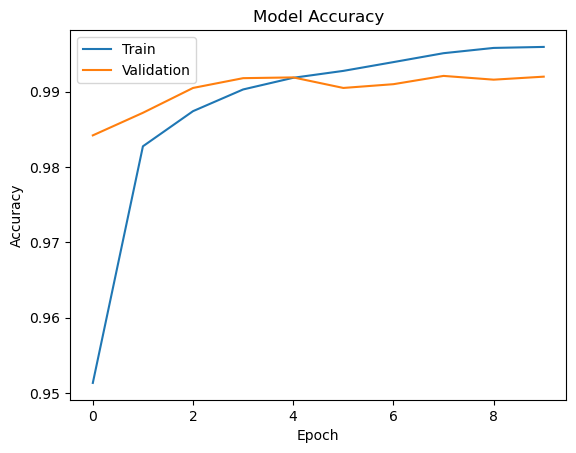

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

In [53]:
#Step 9: Confusion Matrix:

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


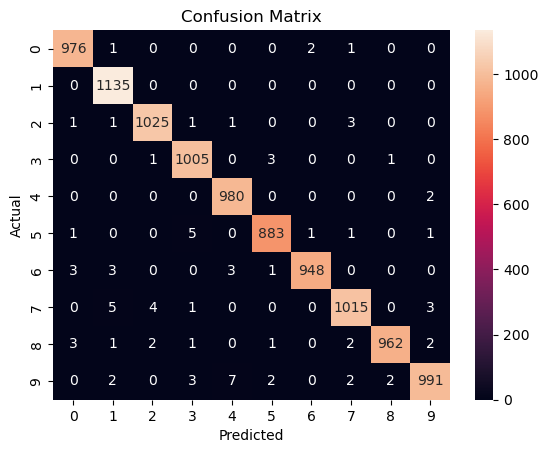

In [54]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

cm = confusion_matrix(y_true,y_pred_classes)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
#Step 10: Predict Handwritten Digit:

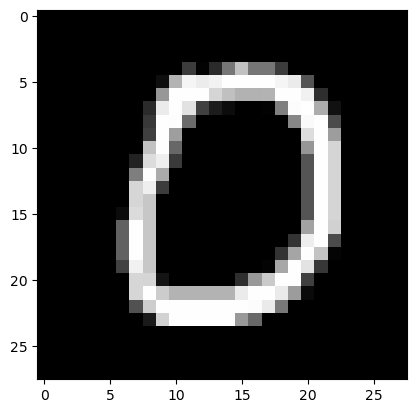

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Predicted Digit: 0


In [56]:
index = 10

plt.imshow(X_test[index].reshape(28,28),cmap='gray')
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28,1))
print("Predicted Digit:", np.argmax(prediction))

In [62]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Reshape
from tensorflow.keras.layers import LSTM, Bidirectional, Input
from tensorflow.keras.models import Model
import numpy as np

In [63]:
characters = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
char_to_num = tf.keras.layers.StringLookup(vocabulary=list(characters), mask_token=None)
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), invert=True, mask_token=None
)

In [64]:
img_width = 128
img_height = 32

def preprocess_image(image):
    image = tf.image.resize(image, [img_height, img_width])
    image = tf.image.rgb_to_grayscale(image)
    image = image / 255.0
    return image

In [65]:
input_img = Input(shape=(img_height, img_width, 1), name="image")

x = Conv2D(32, (3,3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D((2,2))(x)

# reshape CNN output to sequence
new_shape = ((img_width // 8), (img_height // 8) * 128)
x = Reshape(target_shape=new_shape)(x)

# RNN layers
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# Output layer
output = Dense(len(characters) + 1, activation="softmax")(x)

model = Model(inputs=input_img, outputs=output)
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 32, 128, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 128, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 16, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 8, 32, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 8, 32, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 16, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 16, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 16, 256)             │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 16, 128)             │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16, 63)              │           8,127 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 921,535 (3.52 MB)

 Trainable params: 921,535 (3.52 MB)

 Non-trainable params: 0 (0.00 B)